# The transient Universe

In [1]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import uniform

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
import emcee
import corner

Data is a (100 x 3) array, containing some time-series measurements from a transient phenomenon: we have time, flux and error on flux (homoscedastic)

visualize data

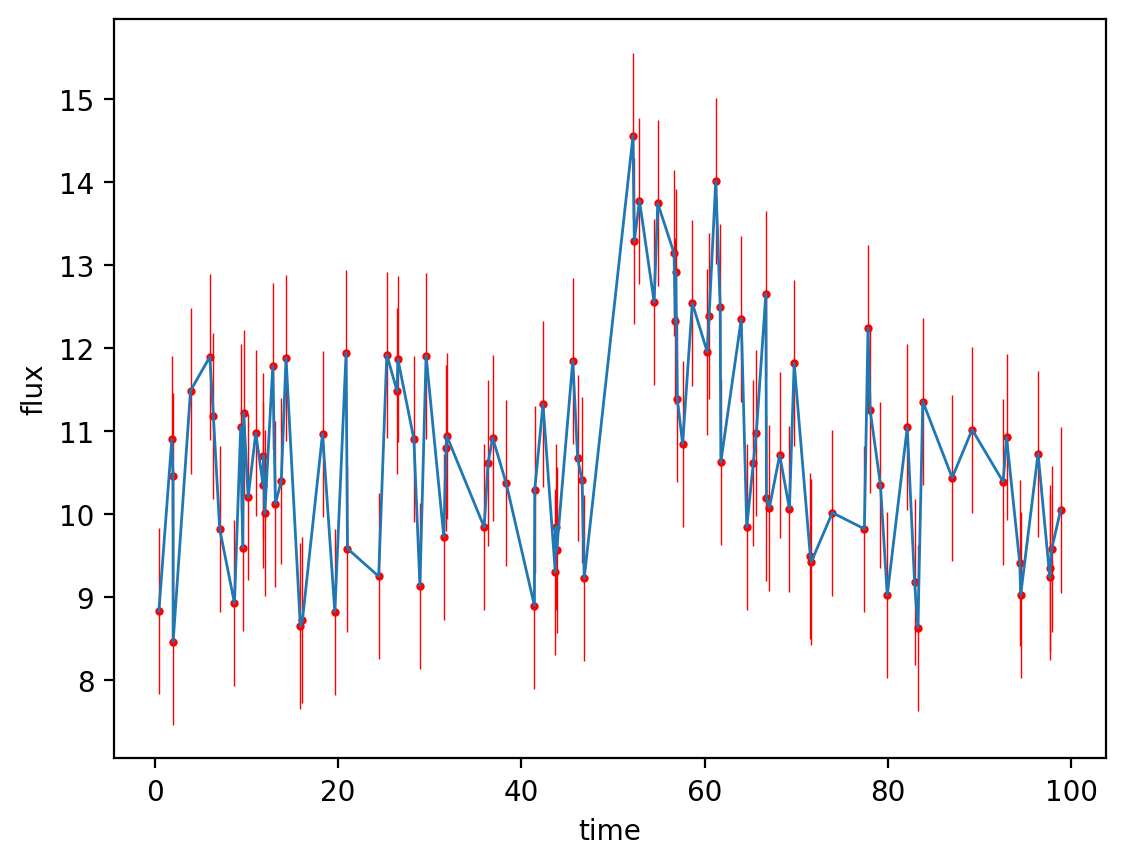

In [3]:
data=np.load('transient.npy')

time,flux,error=data.T
plt.scatter(time,flux,s=4,color='red')
plt.errorbar(time,flux,error,ecolor='red',elinewidth=0.5, lw=1)
plt.xlabel("time")
plt.ylabel("flux");

The model is a sharp burst with an exponential tail rising above a nominal background level

In [4]:
def model(par, t):
    b,A,t0,alpha=par 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

Parameters of the model are: b background amplitude, A burst amplitude, t_0 time of burst, alpha encodes how rapidly the exponential declines

Visualize the model with naive guesses on the parameters

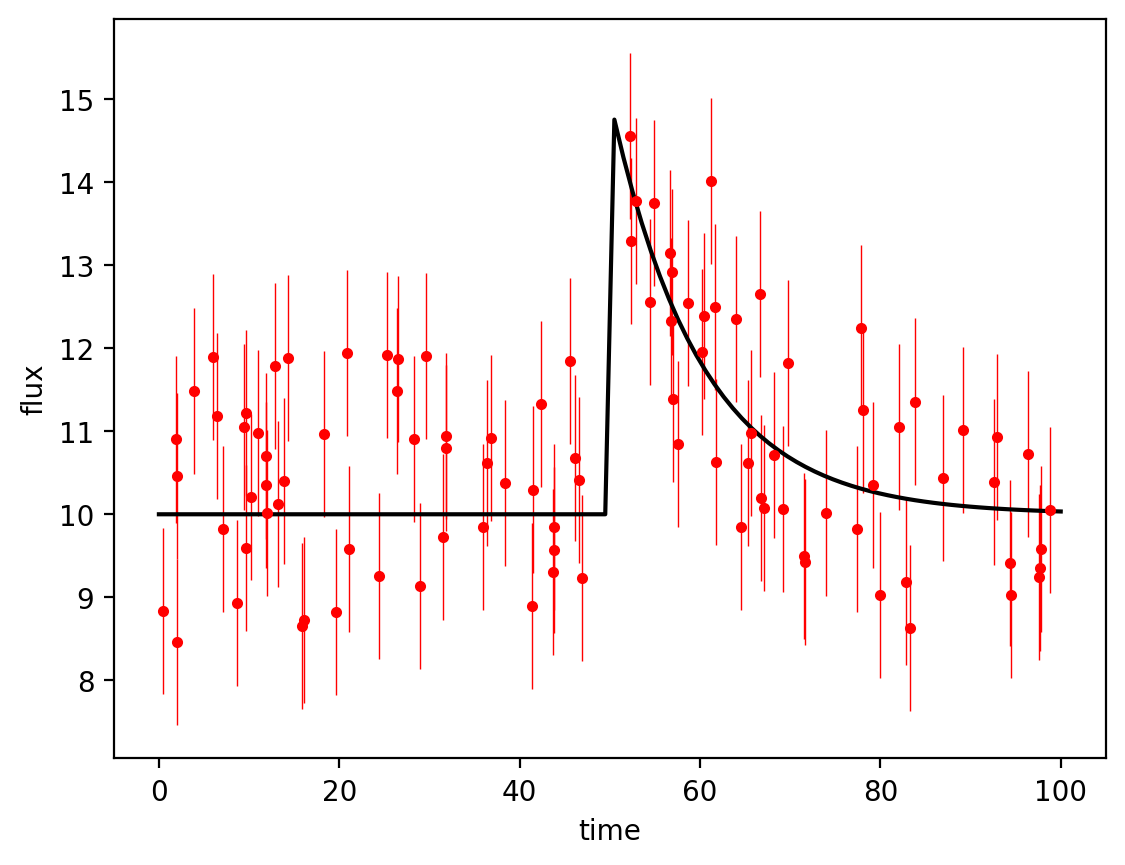

In [5]:
tgrid=np.linspace(0,100,100)
t0_guess=50
A_guess=5
b_guess=10
alpha_guess=0.1


par_guess= np.array([b_guess,A_guess,t0_guess,alpha_guess])
ygrid =  model(par_guess,tgrid)

plt.errorbar(time,flux,error, fmt='.', color='red', ecolor='red',elinewidth=0.5, lw=1)
plt.xlabel("time")
plt.ylabel("flux")
plt.plot(tgrid,ygrid, c='k',lw=1.5);

Write Likelihood and Prior

In [6]:
def LogLikelihood(par, data, model):
    t, f, sigma_f = data.T
    f_model = model(par, t)
    return -0.5 * np.sum((f-f_model)**2 / sigma_f**2 ) 

In [7]:
def Logprior(par):
    prior_b = stats.uniform(0,50).pdf(par[0])
    prior_A = stats.uniform(0,50).pdf(par[1])
    prior_t0 = stats.uniform(0,100).pdf(par[2])
    prior_alpha = stats.uniform(-5,5).pdf(np.log(par[3]))

    logPrior = np.log(prior_b * prior_A * prior_t0 * prior_alpha)
    if np.isfinite(logPrior):
        return logPrior
    else:
        return -np.inf

Posterior=Likelihood*Prior or logPos=logL+LogPr

In [8]:
def LogPosterior(par,data, model):
    return LogLikelihood(par,data,model) + Logprior(par)

Perform Bayesian analysis using an MCMC sampler (emcee)

In [9]:
ndim = 4             # number of model parameters we want to recover
nwalkers = 20        # MCMC walkers
nsteps = 10000       # steps for each walker

starting_guesses = par_guess + 1e-1*np.random.randn(nwalkers, ndim)

In [10]:
starting_guesses.shape

(20, 4)

In [11]:
#parameters=[b,A,t_0,alhpa]

In [12]:
sampler=emcee.EnsembleSampler(nwalkers,ndim, LogPosterior, args=[data, model])
sampler.run_mcmc(starting_guesses, nsteps, progress=True);

/var/folders/6b/czhl7w9x0f5_6ryysjt3f5q00000gn/T/ipykernel_59188/2715553161.py:5: RuntimeWarning: invalid value encountered in log
  prior_alpha = stats.uniform(-5,5).pdf(np.log(par[3]))
  0%|                                                                        | 0/10000 [00:00<?, ?it/s]/Users/beatricetonello/opt/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/var/folders/6b/czhl7w9x0f5_6ryysjt3f5q00000gn/T/ipykernel_59188/2715553161.py:7: RuntimeWarning: divide by zero encountered in log
  logPrior = np.log(prior_b * prior_A * prior_t0 * prior_alpha)
100%|████████████████████████████████████████████████████████████| 10000/10000 [14:14<00:00, 11.71it/s]


our chain is 10000 values for each of the 20 walkers for each of the 4 parameters

In [13]:
print(sampler.chain.shape)

(20, 10000, 4)


Visualize trace-plots

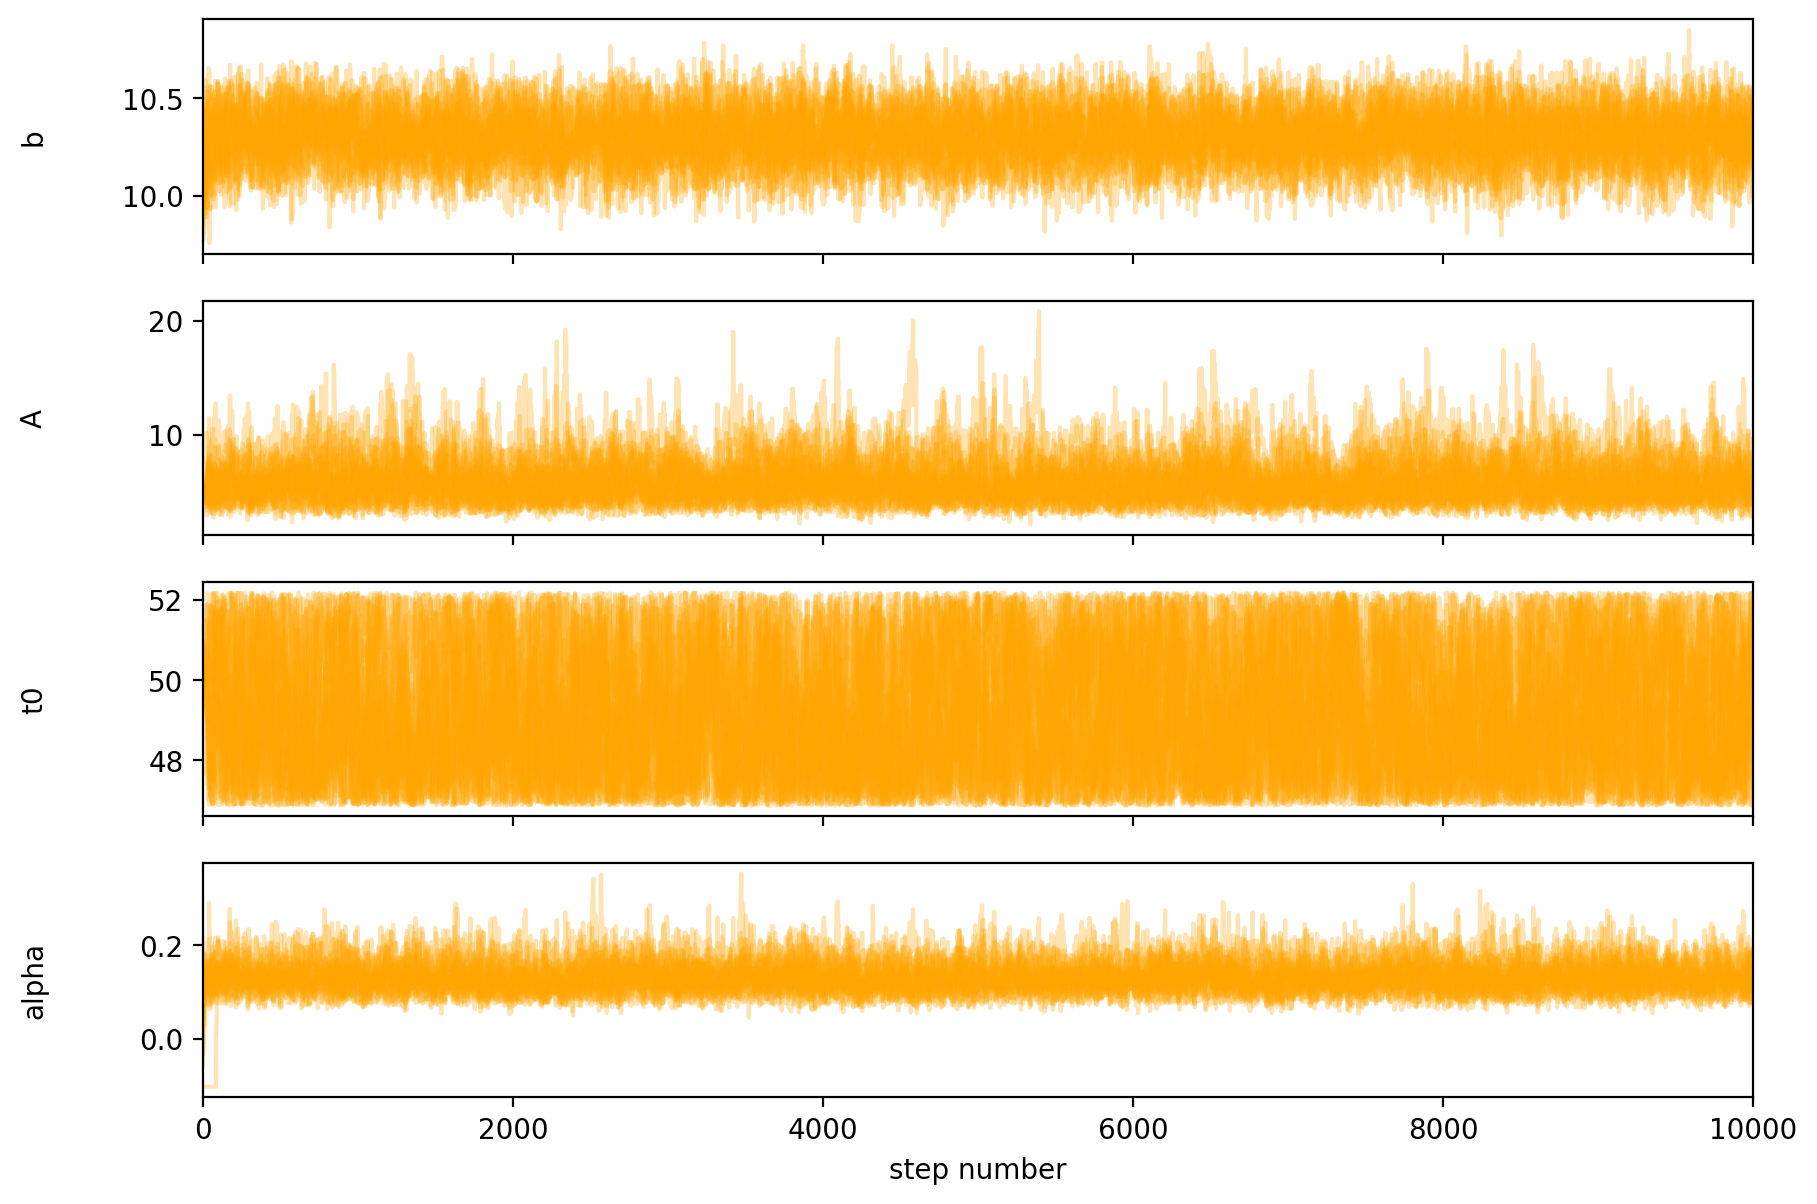

In [14]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["b","A","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "orange", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

compute autocorrelation times for each parameters and pick the max to thin the chain. The burn is chosen to be 3 times larger than the max autocorrelation time

In [15]:
tau = sampler.get_autocorr_time()
print(tau)

[55.22052079 75.07011352 80.14339787 57.16050652]


We discard the burn-in period, thin the chain and flatten the chain (put together the 20 walkers)

In [16]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(2440, 4)


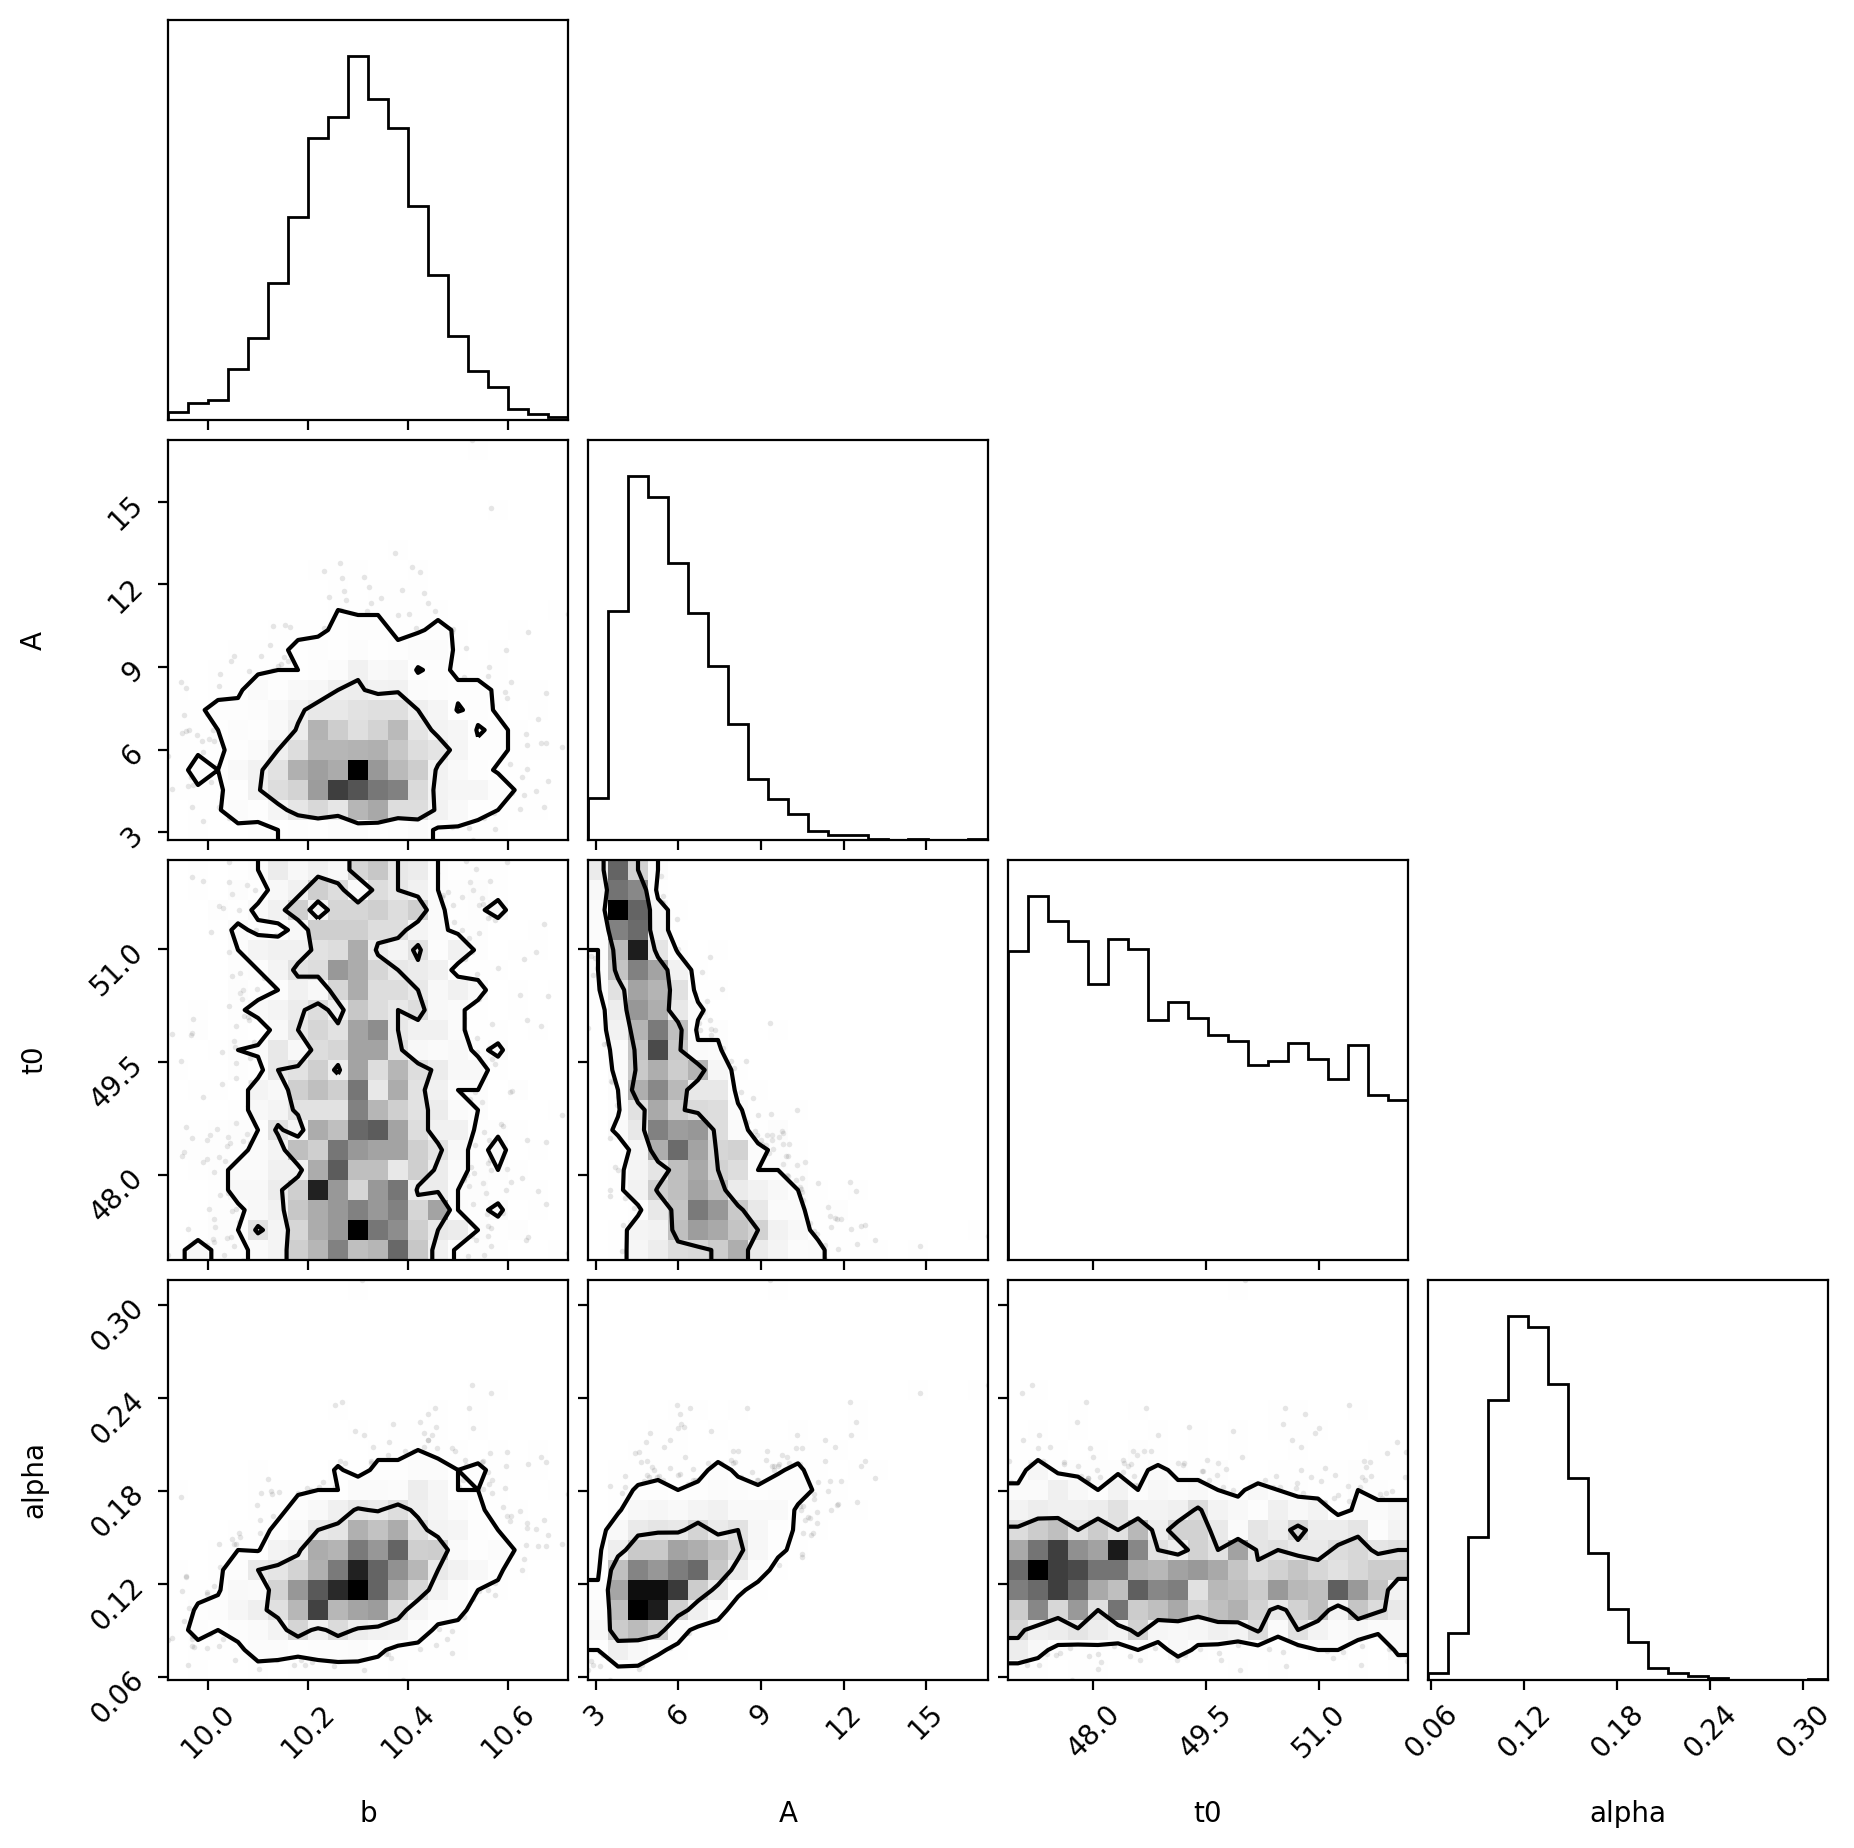

In [17]:
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95]);

We recover the parameters of the model (low=5th percentile, up=95th percentile, med=median, to show the 90% credible regions)

In [18]:
for i,l in enumerate(labels):
    low,med,up = np.percentile(flat_samples[:,i],[5,50,95]) 
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

b   10.302294970237856 +0.20822721114005205 -0.20222183467967625
A   5.585766125950151 +3.5838655271328026 -1.8999012197943537
t0   48.98982606826678 +2.750567785984636 -1.9010995662337322
alpha   0.12741408656984649 +0.052963092697692504 -0.038864983533157246


Corner plot showing 68,95 levels and quantiles

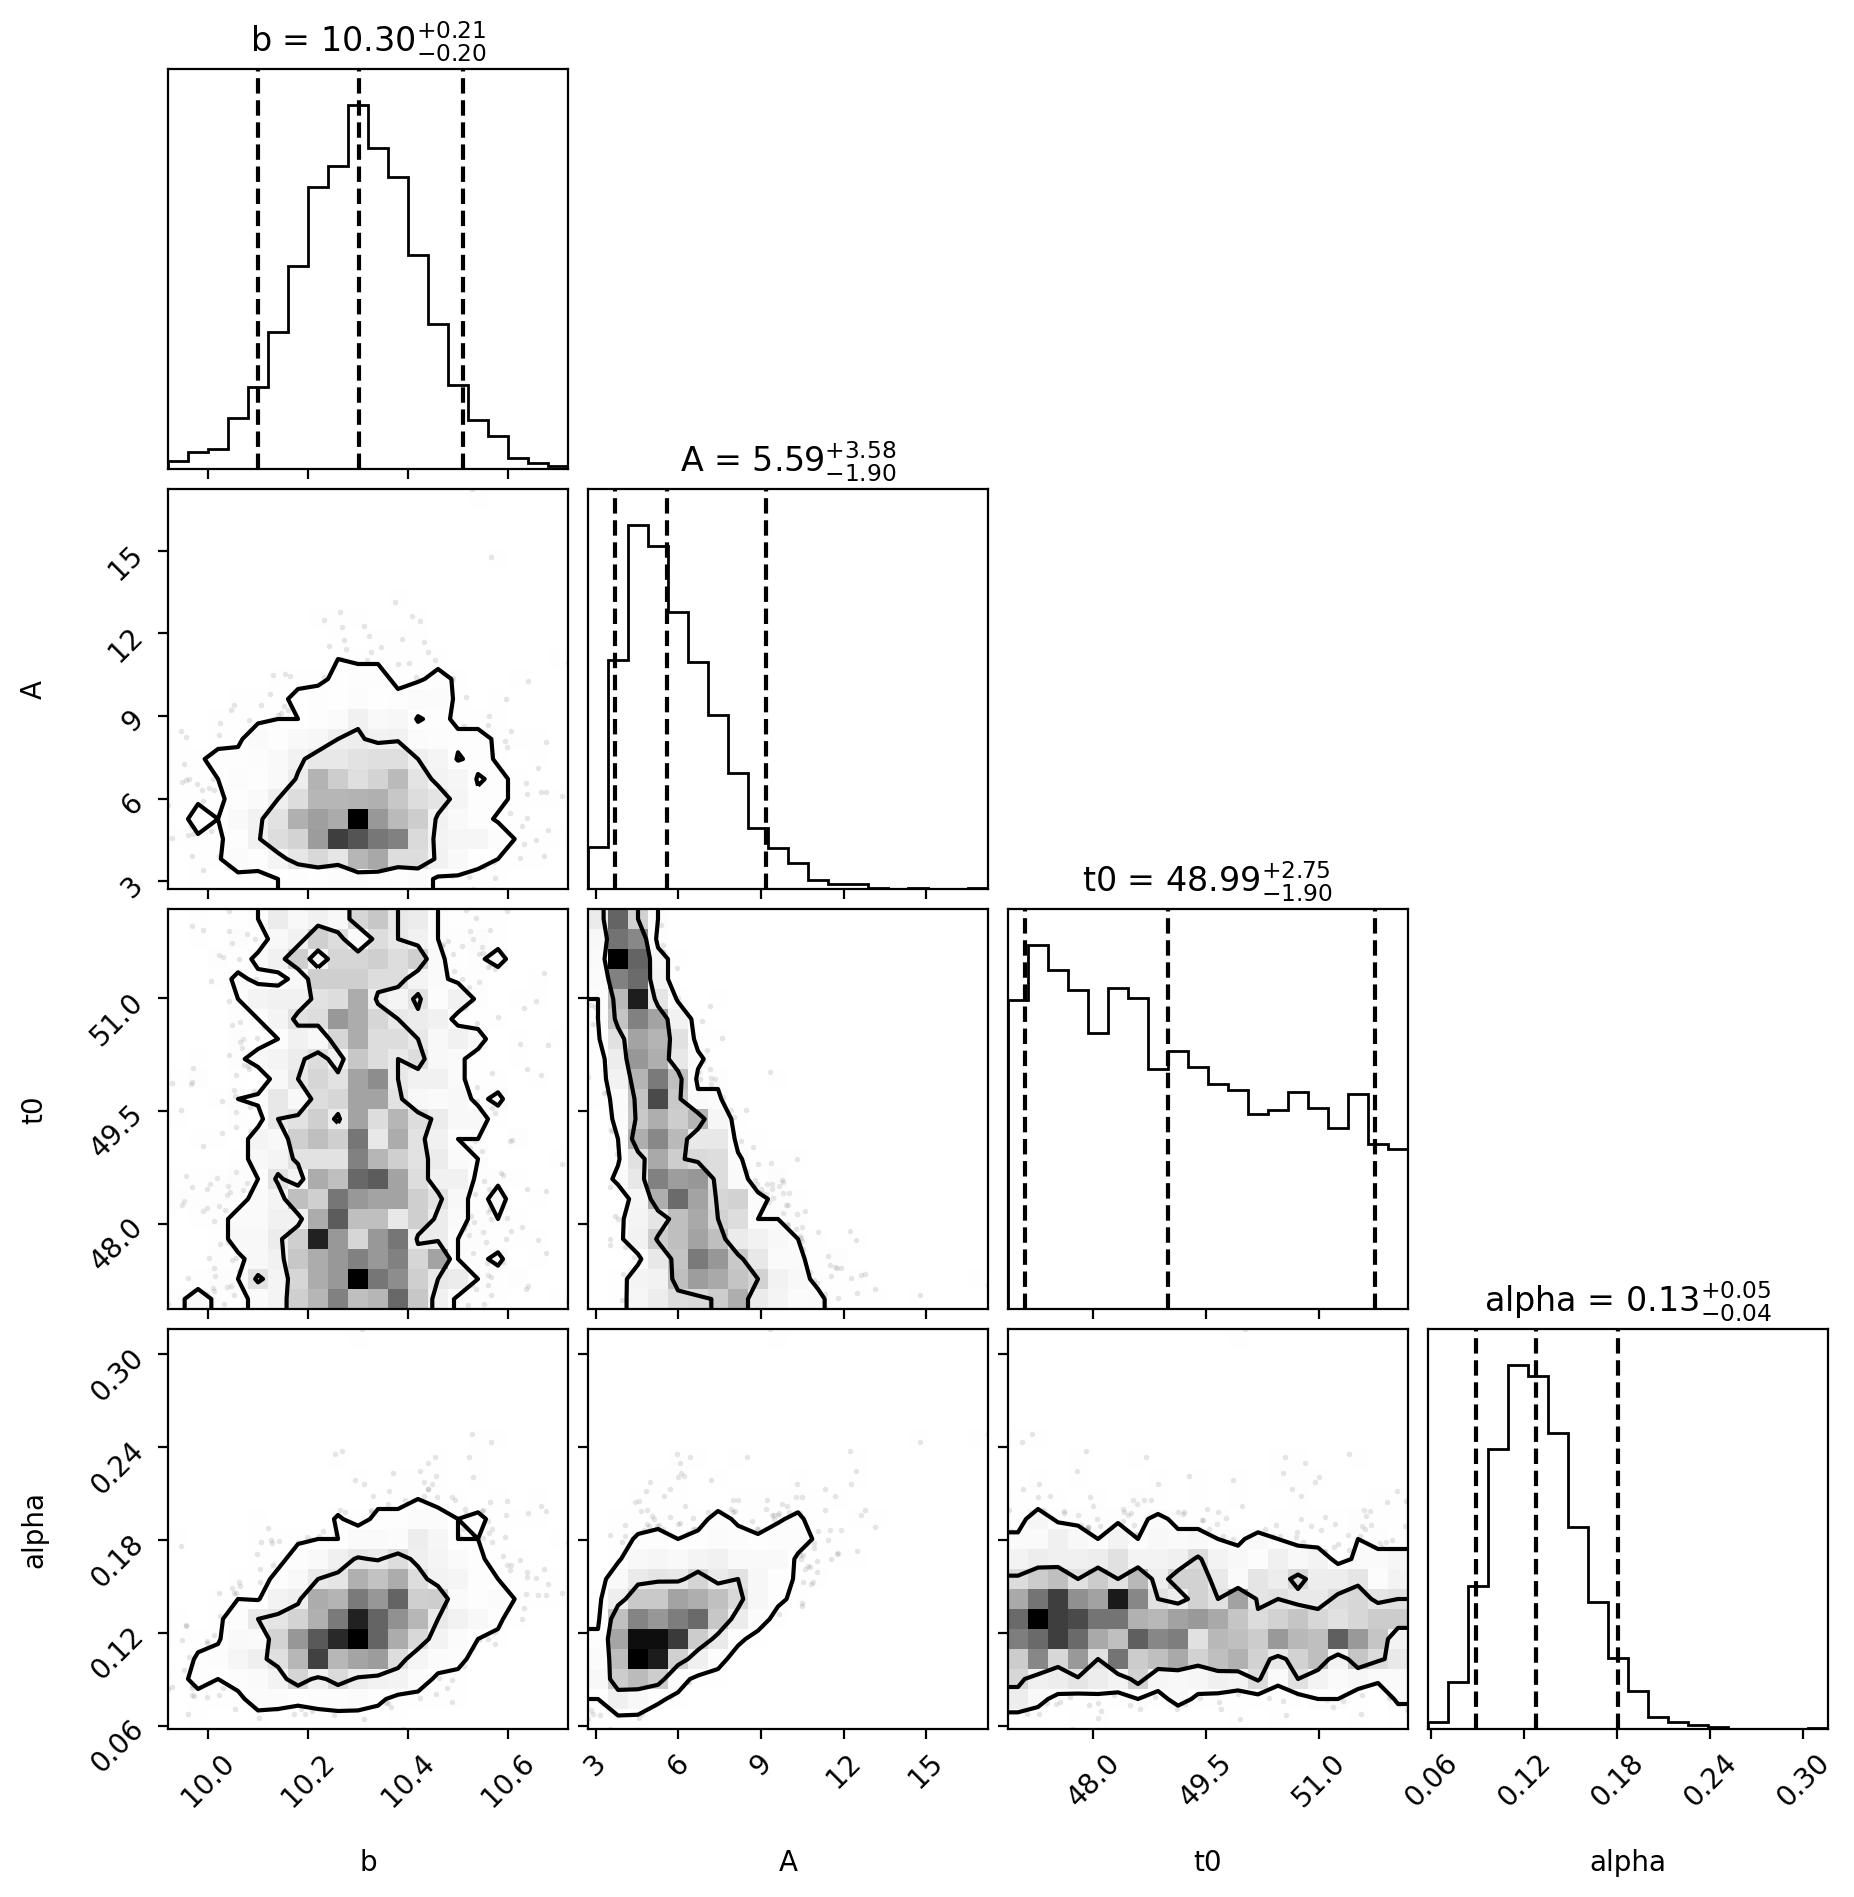

In [23]:
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95],
                   quantiles=[0.05, 0.5, 0.95], show_titles=True, title_fmt=".2f",
                   plot_density=True) 

Then choose 30 random sets of parameters from our samples and plot the models over our data

In [20]:
par_samples= flat_samples[np.random.choice(len(flat_samples),size=30)]

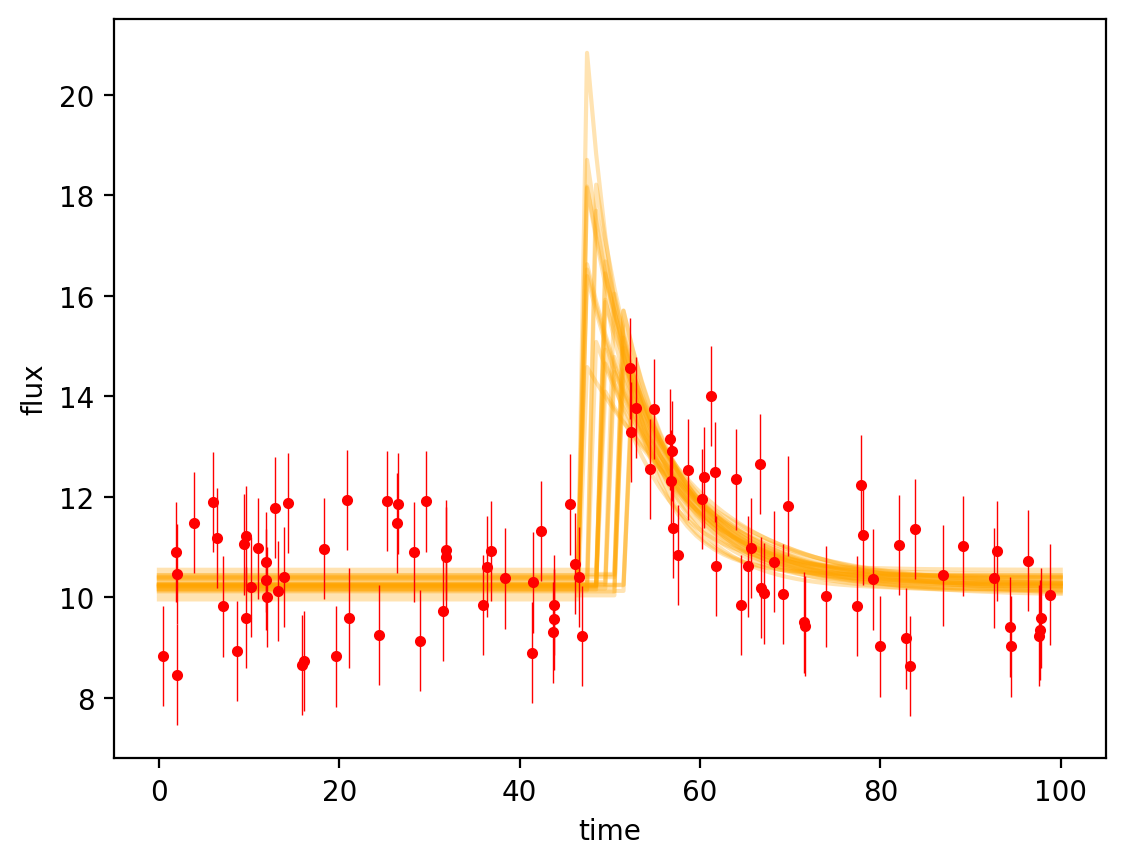

In [21]:
tgrid=np.linspace(0,100,100)

for params in par_samples:

    ygrid =  model(params,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='orange')
    
#plt.scatter(time,flux,s=4,color='C0')
plt.errorbar(time,flux,error, fmt='.', color='red', ecolor='red',elinewidth=0.5, lw=1)
plt.xlabel("time")
plt.ylabel("flux");